Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
複数のデータフレームを横断的に処理する事例。3成分で相互平衡になっている。  
1. 未知の速度定数を含む、csvに書き込んだ反応式を読み込む。  
2. 化学種の濃度の経時変化の実験データを読み込む。初期濃度を変化させた複数の条件での実験結果を用い、全体を最適化できる速度定数を求めることを目標とする。  
3. 化学種ごとの微分型の反応速度式を作成する。速度定数が未知の素反応にはシンボリックな変数が割り振られる。  
4. 作成した微分方程式を、数値解析可能な形式にする。  
5. **P0OptFit**（Optuna）で初期パラメータ p0 を探索し、最適な p0 で **ExpDataFitSci** により速度定数をフィッティングする。本ノートブックでは use_log_fit=True を用いる。  
6. 経時変化を図示する。  

残念ながら、df2の結果を再現できていない。複数のデータフレームを横断的に処理する実行例として掲載する。  

## 反応式を記載したcsvファイルを指定する  

In [1]:
file_path_rxn = './sample_data/ref5/sample_rxn_ref5.csv'  # CSVファイルのパスを指定

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [2]:
import time #15番目のセル、Optunaで初期値最適化後データにフィットさせる処理の計時  

import numpy as np
import pandas as pd

from rxnfit import RxnODEbuild, SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read
from rxnfit.expdata_fit_sci import ExpDataFitSci
from rxnfit.p0_opt_fit import P0OptFit


# 反応速度式の作成

In [3]:
builded_rxnode = RxnODEbuild(file_path_rxn)

In [4]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 3
unique species: ['oXy', 'pXy', 'mXy']
rate constant: {'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'k5': k5, 'k6': k6}

=== debug info ===
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']
order of args: ['t', 'oXy', 'pXy', 'mXy']
system of ODE: {'oXy': '-1/1*k1*oXy(t)+1/1*k2*pXy(t)-1/1*k3*oXy(t)+1/1*k4*mXy(t)', 'pXy': '1/1*k1*oXy(t)-1/1*k2*pXy(t)-1/1*k5*pXy(t)+1/1*k6*mXy(t)', 'mXy': '1/1*k3*oXy(t)-1/1*k4*mXy(t)+1/1*k5*pXy(t)-1/1*k6*mXy(t)'}


In [5]:
# 作成した微分方程式
builded_rxnode.get_ode_system()[0]

Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


[Eq(Derivative(oXy(t), t), -k1*oXy(t) + k2*pXy(t) - k3*oXy(t) + k4*mXy(t)),
 Eq(Derivative(pXy(t), t), k1*oXy(t) - k2*pXy(t) - k5*pXy(t) + k6*mXy(t)),
 Eq(Derivative(mXy(t), t), k3*oXy(t) - k4*mXy(t) + k5*pXy(t) - k6*mXy(t))]

In [6]:
# 速度定数の確認
print(builded_rxnode.rate_consts_dict)

check_type = [v for v in builded_rxnode.rate_consts_dict.values()]
[type(e) for e in check_type]

{'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'k5': k5, 'k6': k6}


[sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol]

## 経時変化の実験データを読み込み　　
### データフレーム化  

In [7]:
df1 = pd.read_csv(f'./sample_data/ref5/ref5_df1.csv')
df2 = pd.read_csv(f'./sample_data/ref5/ref5_df2.csv')
df3 = pd.read_csv(f'./sample_data/ref5/ref5_df3.csv')
df4 = pd.read_csv(f'./sample_data/ref5/ref5_df4.csv')

# plot_datasets で名前指定する場合、df.attrs['name'] を設定（省略可）
df1.attrs['name'] = 'df1'
df2.attrs['name'] = 'df2'
df3.attrs['name'] = 'df3'
df4.attrs['name'] = 'df4'

expdata_read([df1, df2, df3, df4])  # 複数データフレームのリストを渡すとまとめて読み込み可能

[([array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ]),
   array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ]),
   array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ])],
  [array([0.999, 0.95 , 0.846, 0.738, 0.632, 0.434, 0.19 , 0.175, 0.187]),
   array([0.   , 0.048, 0.148, 0.241, 0.328, 0.478, 0.632, 0.627, 0.602]),
   array([0.001, 0.002, 0.006, 0.021, 0.04 , 0.088, 0.178, 0.198, 0.211])]),
 ([array([ 0,  1,  2,  3,  5,  8, 12, 22, 46]),
   array([ 0,  1,  2,  3,  5,  8, 12, 22, 46]),
   array([ 0,  1,  2,  3,  5,  8, 12, 22, 46])],
  [array([0.005, 0.006, 0.026, 0.02 , 0.046, 0.089, 0.114, 0.144, 0.174]),
   array([0.986, 0.973, 0.933, 0.918, 0.86 , 0.768, 0.709, 0.647, 0.609]),
   array([0.009, 0.021, 0.041, 0.062, 0.094, 0.143, 0.177, 0.209, 0.217])]),
 ([array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ]),
   array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ]),
   array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ])],
  [array([0.001, 0.00

### フィッティング  
P0OptFit に RxnODEbuild のインスタンスと df_list を渡し、Optuna で初期値 p0 を最適化したうえで ExpDataFitSci によりフィッティングする。  


In [8]:
t_cpu_start = time.process_time() # CPU時間計測

# P0OptFit: RxnODEbuild インスタンスと df_list を渡す（他は最小限）
opt = P0OptFit(builded_rxnode, [df1, df2, df3, df4], seed=123)
result_dict, fit_metrics = opt.optimize(n_trials=20)

# プロット用に最適 p0 で ExpDataFitSci を1回実行し、config を取得
keys = builded_rxnode.get_symbolic_rate_const_keys()
p0_best = [result_dict[k][1] for k in keys]
t_range = (0, max(float(df.iloc[:, 0].max()) for df in [df1, df2, df3, df4]))
fit_sci = ExpDataFitSci(builded_rxnode, [df1, df2, df3, df4], t_range)
fit_sci.run_fit(p0_best, use_log_fit=True, lower_bound=1e-10)

t_cpu_end = time.process_time()
elapsed = t_cpu_end - t_cpu_start
h, r = divmod(int(elapsed), 3600)
m, s = divmod(r, 60)
print(f"CPU time: {h:02d}:{m:02d}:{s:02d}")

[I 2026-03-14 16:25:38,505] A new study created in memory with name: no-name-5d497e4d-3780-41e6-a952-0a8d10d21456


  0%|          | 0/20 [00:00<?, ?it/s]

Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']
[I 2026-03-14 16:25:42,988] Trial 0 finished with value: 0.13621747553294597 and parameters: {'k1': 0.09219170692219454, 'k2': 7.267639045471199e-06, 'k3': 1.855728918810948e-06, 'k4': 0.003259475273606692, 'k5': 0.15656320308475058, 'k6': 0.00017024117230719408}. Best is trial 0 with value: 0.13621747553294597.
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']
[I 2026-03-14 16:40:20,350] Trial 1 finished with value: 2.045893707100747 and parameters: {'k1': 64.21581278784039, 'k2': 0.07051757771805378, 'k3': 0.0006446426195647978, 'k4': 8.340175355380263e-05, 'k5': 2.702589975314762e-05,


=== Time-course plot ===


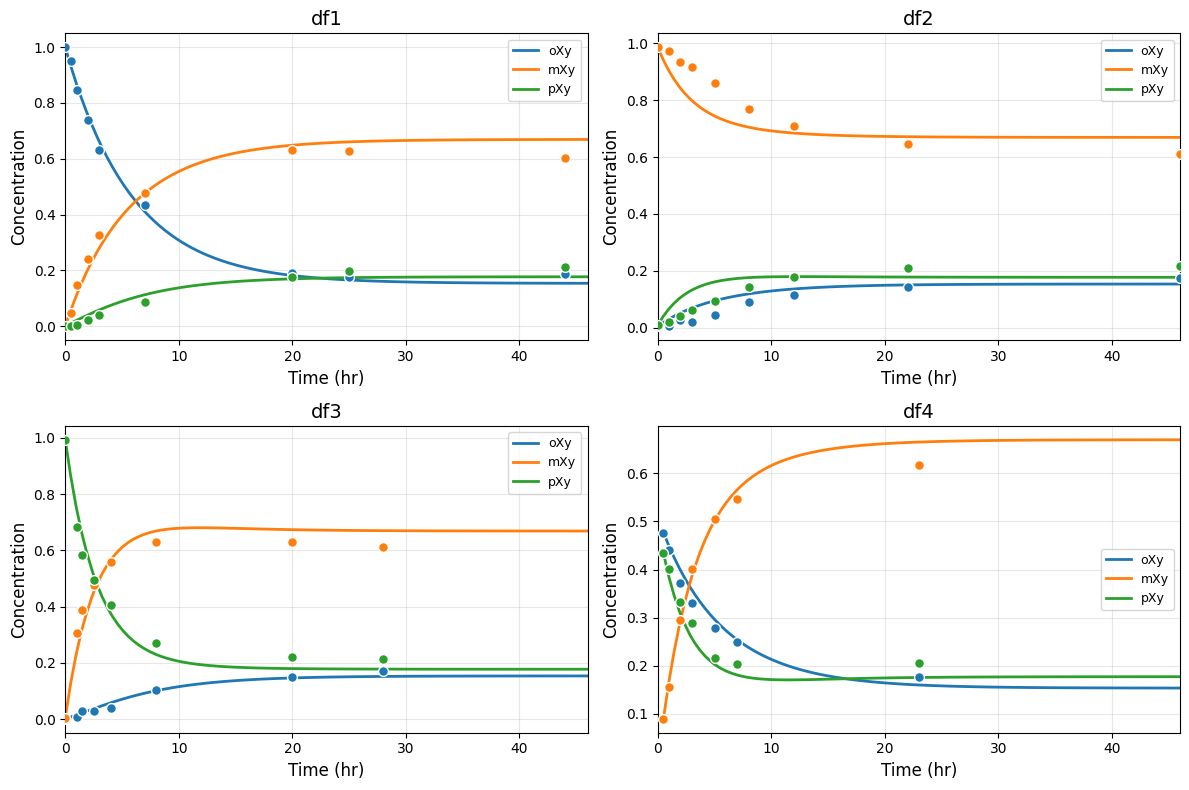


=== Concentration at the final time point ===
df1:
  oXy: 0.153910
  mXy: 0.668916
  pXy: 0.177174
df2:
  oXy: 0.153511
  mXy: 0.669210
  pXy: 0.177279
df3:
  oXy: 0.153322
  mXy: 0.668567
  pXy: 0.177111
df4:
  oXy: 0.153850
  mXy: 0.669742
  pXy: 0.177407


In [9]:
# 経時変化を図示（plot_fitted_solution を使用）
fit_sci.plot_fitted_solution(
    expdata_df=[df1, df2, df3, df4], 
    species=['oXy', 'mXy', 'pXy'], 
    subplot_layout=(2,2)
    )

In [10]:
# 最適化された k1–k6 と metrics の再表示
keys = builded_rxnode.get_symbolic_rate_const_keys()
print("Fitted rate constants:")
for k in keys:
    p0_val, fitted_val = result_dict[k]
    print(f"  {k}: p0={p0_val:.6g}, fitted={fitted_val:.6g}")
print("\nFit metrics:")
for name, val in fit_metrics.items():
    print(f"  {name}: {val:.6g}")

Fitted rate constants:
  k1: p0=0.0153416, fitted=0.0208643
  k2: p0=0.000450525, fitted=0.0127115
  k3: p0=0.564529, fitted=0.123445
  k4: p0=0.0118918, fitted=0.0297495
  k5: p0=4.40818e-07, fitted=0.28386
  k6: p0=6.82589e-07, fitted=0.0737744

Fit metrics:
  rss: 0.136217
  tss: 6.63985
  r2: 0.979485
